
===== MEAN + SEM TABLE =====
     Set       Bz Enantiomer  Diameter_mean  Diameter_SEM  \
0   Set1  +1.6 mT     D-AHPA      -0.113888      0.014623   
1   Set1  -1.6 mT     D-AHPA      -0.104286      0.017228   
2   Set2  +1.6 mT     D-AHPA      -0.064185      0.012930   
3   Set2  -1.6 mT     D-AHPA       0.169623      0.015865   
4   Set3  +1.6 mT     D-AHPA       0.143627      0.013419   
5   Set3  -1.6 mT     D-AHPA      -0.083315      0.017839   
6   Set1  +1.6 mT     L-AHPA      -0.073976      0.013916   
7   Set1  -1.6 mT     L-AHPA      -0.154650      0.013875   
8   Set2  +1.6 mT     L-AHPA      -0.355851      0.012289   
9   Set2  -1.6 mT     L-AHPA       0.154578      0.012844   
10  Set3  +1.6 mT     L-AHPA      -0.053365      0.017605   
11  Set3  -1.6 mT     L-AHPA      -0.286690      0.015188   

    Sk-Sk Distance_mean  Sk-Sk Distance_SEM  Shape factor_mean  \
0              0.024365            0.009888          -0.001199   
1              0.057668            0.012375 

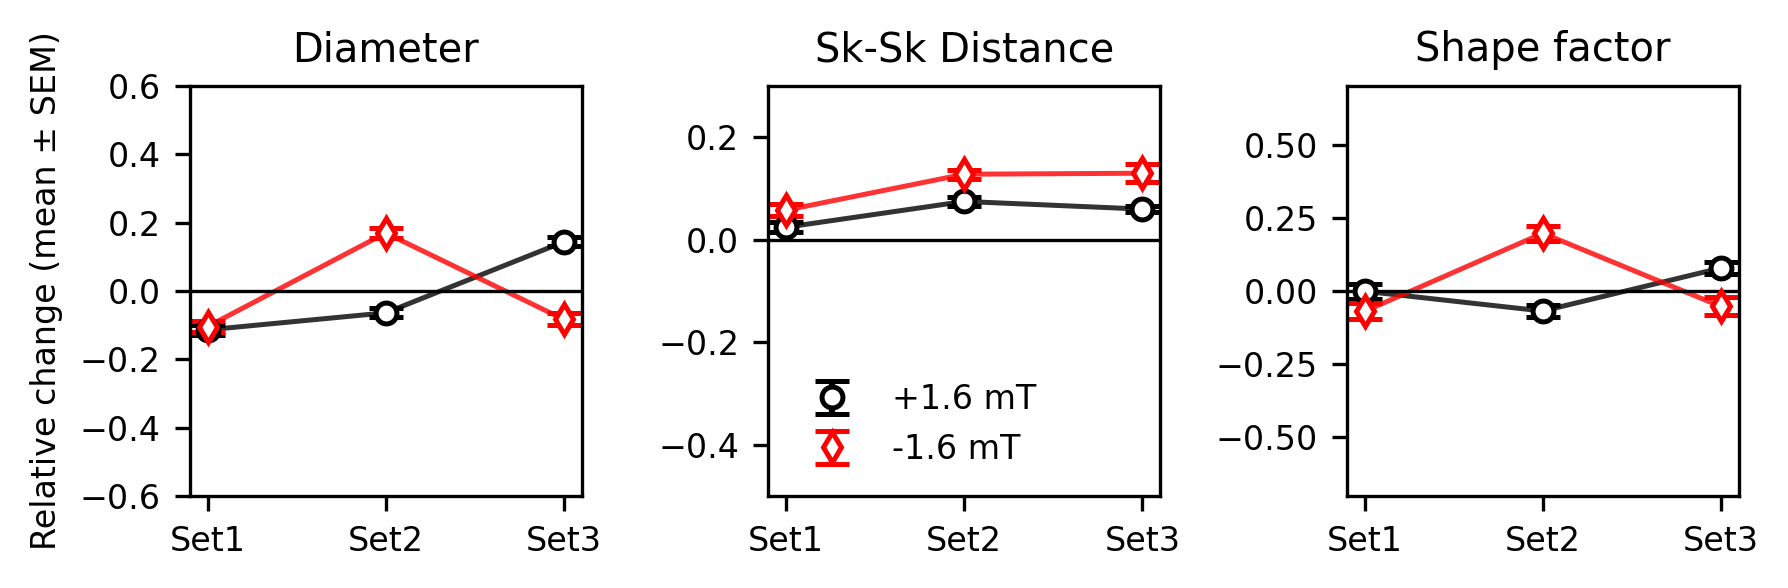

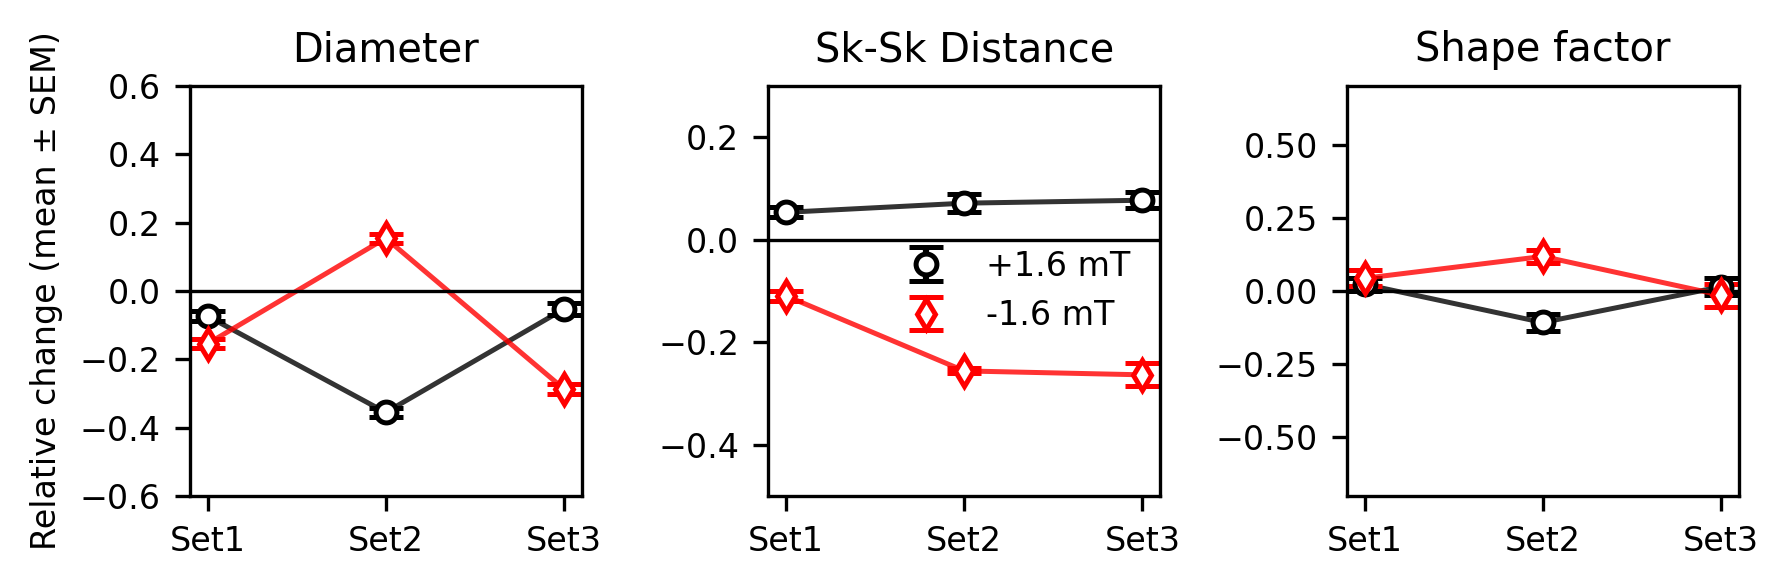

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Style
# ==============================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 8,
    "axes.linewidth": 0.8,
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

pixel_to_um = 0.325

# ==============================
# DATASETS
# ==============================
sets = {
    "Set1": {"+": r"/Users/buddhikadezoysa/Downloads/Supplimantary/stats/Bz_1",
             "-": r"/Users/buddhikadezoysa/Downloads/Supplimantary/stats/-Bz_1"},
    "Set2": {"+": r"/Users/buddhikadezoysa/Downloads/Supplimantary/stats/Bz_2",
             "-": r"/Users/buddhikadezoysa/Downloads/Supplimantary/stats/-Bz_2"},
    "Set3": {"+": r"/Users/buddhikadezoysa/Downloads/Supplimantary/stats/Bz_3",
             "-": r"/Users/buddhikadezoysa/Downloads/Supplimantary/stats/-Bz_3"}
}

datasets = {
    "D": {
        "Bare": {"sk": "skPD.csv", "sksk": "sk-skPD.csv"},
        "AHPA": {"sk": "skD.csv", "sksk": "sk-skD.csv"}
    },
    "L": {
        "Bare": {"sk": "skPL.csv", "sksk": "sk-skPL.csv"},
        "AHPA": {"sk": "skL.csv", "sksk": "sk-skL.csv"}
    }
}

metrics = ["diam", "dist", "ratio"]
metric_names = ["Diameter", "Sk-Sk Distance", "Shape factor"]

# ==============================
# Y-limits
# ==============================
ylims = {
    "Diameter": (-0.6, 0.6),
    "Sk-Sk Distance": (-0.5, 0.3),
    "Shape factor": (-0.7, 0.7)
}

# ==============================
# Compute mean + SEM
# ==============================
def compute_mean_sem(chem, metric, base_dir):

    if metric == "diam":
        dfP = pd.read_csv(os.path.join(base_dir, datasets[chem]["Bare"]["sk"]))
        dfA = pd.read_csv(os.path.join(base_dir, datasets[chem]["AHPA"]["sk"]))
        col = [c for c in dfP.columns if "Skyrmion diameter" in c][0]
        bare = dfP[col].dropna() * pixel_to_um
        ahpa = dfA[col].dropna() * pixel_to_um

    elif metric == "dist":
        dfP = pd.read_csv(os.path.join(base_dir, datasets[chem]["Bare"]["sksk"]))
        dfA = pd.read_csv(os.path.join(base_dir, datasets[chem]["AHPA"]["sksk"]))
        col = [c for c in dfP.columns if "Skyrmion-Skyrmion distance" in c][0]
        bare = dfP[col].dropna() * pixel_to_um
        ahpa = dfA[col].dropna() * pixel_to_um

    elif metric == "ratio":
        dfP = pd.read_csv(os.path.join(base_dir, datasets[chem]["Bare"]["sk"]))
        dfA = pd.read_csv(os.path.join(base_dir, datasets[chem]["AHPA"]["sk"]))
        col = [c for c in dfP.columns if "diameter to convex hull diameter ratio" in c][0]
        bare = dfP[col].dropna()
        ahpa = dfA[col].dropna()

    mean_bare = bare.mean()
    rel = (ahpa - mean_bare) / mean_bare

    mean = np.mean(rel)
    std = np.std(rel, ddof=1)
    sem = std / np.sqrt(len(rel))

    return mean, sem


# ==============================
# BUILD TABLE
# ==============================
rows = []

for chem in ["D", "L"]:
    for set_name, dirs in sets.items():
        for polarity, label in zip(["+", "-"], ["+1.6 mT", "-1.6 mT"]):

            base_dir = dirs[polarity]

            row = {
                "Set": set_name,
                "Bz": label,
                "Enantiomer": f"{chem}-AHPA"
            }

            for metric, name in zip(metrics, metric_names):
                mean, sem = compute_mean_sem(chem, metric, base_dir)

                row[f"{name}_mean"] = mean
                row[f"{name}_SEM"] = sem

            rows.append(row)

df_table = pd.DataFrame(rows)
df_table.to_csv("Skyrmion_relative_change_mean_SEM.csv", index=False)

print("\n===== MEAN + SEM TABLE =====")
print(df_table)


# ==============================
# PLOT (Improved visibility)
# ==============================
def plot_summary(chem):

    fig, axes = plt.subplots(1, 3, figsize=(6, 2))

    for i, metric in enumerate(metric_names):

        ax = axes[i]

        for polarity, marker, color in zip(
            ["+1.6 mT", "-1.6 mT"],
            ["o", "d"],
            ["black", "red"]
        ):

            subset = df_table[
                (df_table["Enantiomer"] == f"{chem}-AHPA") &
                (df_table["Bz"] == polarity)
            ]

            x = np.arange(len(subset))

            mean = subset[f"{metric}_mean"].values
            sem = subset[f"{metric}_SEM"].values

            # 🔹 CONNECTING LINE (key improvement)
            ax.plot(
                x,
                mean,
                color=color,
                linewidth=1.2,
                alpha=0.8
            )

            # 🔹 POINT + ERROR
            ax.errorbar(
                x,
                mean,
                yerr=sem,
                fmt=marker,
                markersize=5,
                markerfacecolor='white',
                markeredgewidth=1.2,
                color=color,
                ecolor=color,
                elinewidth=1.5,
                capsize=4,
                capthick=1.5,
                label=polarity
            )

        ax.axhline(0, color='black', linewidth=0.8)

        ax.set_ylim(ylims[metric])
        ax.set_xticks(x)
        ax.set_xticklabels(subset["Set"])
        ax.set_title(metric)

    axes[0].set_ylabel("Relative change (mean ± SEM)")
    axes[1].legend(frameon=False)

    plt.tight_layout()
    plt.savefig(f"{chem}_summary_connected.pdf")
    plt.show()


# ==============================
# RUN
# ==============================
plot_summary("D")
plot_summary("L")

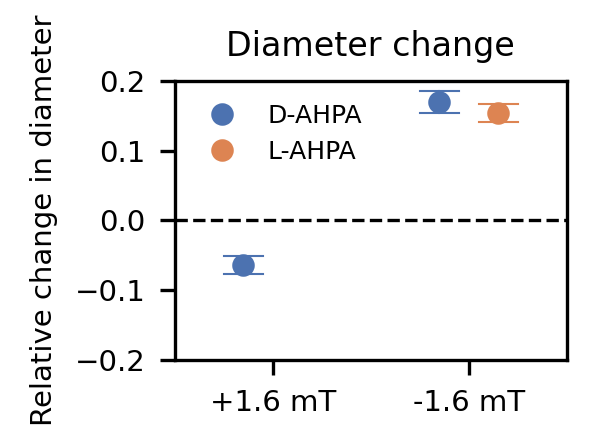

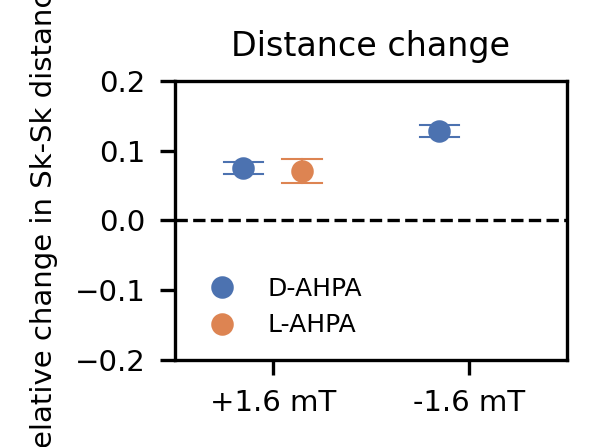

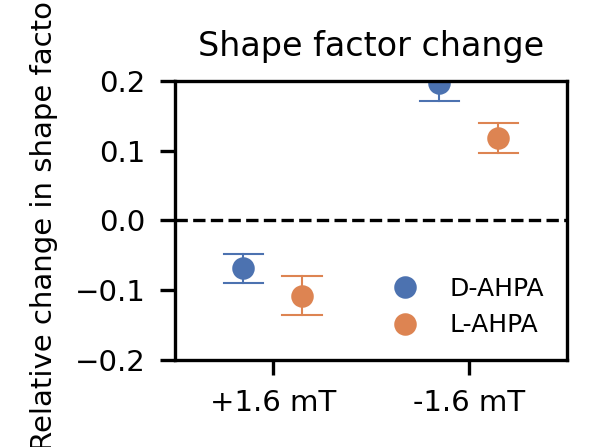

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Plot style
# ==============================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 7,
    "axes.linewidth": 0.8,
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

#base_dir_positive = r"/Users/buddhikadezoysa/Downloads/Supplimantary/stats/Bz_1"
#base_dir_negative = r"/Users/buddhikadezoysa/Downloads/Supplimantary/stats/-Bz_1"

base_dir_positive = r"/Users/buddhikadezoysa/Downloads/Supplimantary/stats/Bz_2"
base_dir_negative = r"/Users/buddhikadezoysa/Downloads/Supplimantary/stats/-Bz_2"

#base_dir_pos = r"/Users/buddhikadezoysa/Downloads/Supplimantary/stats/Bz_3"
#base_dir_neg = r"/Users/buddhikadezoysa/Downloads/Supplimantary/stats/-Bz_3"

pixel_to_um = 0.325

datasets = {
    "D": {
        "Bare": {"sk": "skPD.csv", "sksk": "sk-skPD.csv"},
        "AHPA": {"sk": "skD.csv", "sksk": "sk-skD.csv"}
    },
    "L": {
        "Bare": {"sk": "skPL.csv", "sksk": "sk-skPL.csv"},
        "AHPA": {"sk": "skL.csv", "sksk": "sk-skL.csv"}
    }
}

# ==============================
# Palette
# ==============================
palette = {
    "D-AHPA": "#4C72B0",
    "L-AHPA": "#DD8452"
}

# ==============================
# Compute relative change
# ==============================
def compute_relative_enantiomer(chem, metric):

    values = []
    label = "D-AHPA" if chem == "D" else "L-AHPA"

    for base_dir, field_label in [
        (base_dir_positive, "+1.6 mT"),
        (base_dir_negative, "-1.6 mT")
    ]:

        if metric == "diam":

            dfP = pd.read_csv(os.path.join(base_dir, datasets[chem]["Bare"]["sk"]))
            dfA = pd.read_csv(os.path.join(base_dir, datasets[chem]["AHPA"]["sk"]))

            col = [c for c in dfP.columns if "Skyrmion diameter" in c][0]

            bare = dfP[col].dropna() * pixel_to_um
            ahpa = dfA[col].dropna() * pixel_to_um

        elif metric == "dist":

            dfP = pd.read_csv(os.path.join(base_dir, datasets[chem]["Bare"]["sksk"]))
            dfA = pd.read_csv(os.path.join(base_dir, datasets[chem]["AHPA"]["sksk"]))

            col = [c for c in dfP.columns if "Skyrmion-Skyrmion distance" in c][0]

            bare = dfP[col].dropna() * pixel_to_um
            ahpa = dfA[col].dropna() * pixel_to_um

        elif metric == "ratio":

            dfP = pd.read_csv(os.path.join(base_dir, datasets[chem]["Bare"]["sk"]))
            dfA = pd.read_csv(os.path.join(base_dir, datasets[chem]["AHPA"]["sk"]))

            col = [c for c in dfP.columns if "diameter to convex hull diameter ratio" in c][0]

            bare = dfP[col].dropna()
            ahpa = dfA[col].dropna()

        mean_bare = bare.mean()
        rel = (ahpa - mean_bare) / mean_bare

        for v in rel:
            values.append([v, field_label, label])

    return pd.DataFrame(values, columns=["Value", "Field", "Type"])

# ==============================
# Combine D + L
# ==============================
def combine_data(metric):
    df_D = compute_relative_enantiomer("D", metric)
    df_L = compute_relative_enantiomer("L", metric)
    return pd.concat([df_D, df_L], ignore_index=True)

# ==============================
# Plot function (NO LINES)
# ==============================
def mean_sem_combined_plot(data, ylabel, save_name, title, ylim=None):

    fig, ax = plt.subplots(figsize=(2, 1.5))

    sns.pointplot(
        data=data,
        x="Field",
        y="Value",
        hue="Type",
        order=["+1.6 mT", "-1.6 mT"],
        hue_order=["D-AHPA", "L-AHPA"],
        palette=palette,
        errorbar=("se", 1),
        capsize=0.2,
        err_kws={"linewidth": 0.5},
        dodge=0.3,
        markers=".",
        linestyles="none",   # 🔥 THIS REMOVES LINES
        ax=ax
    )

    # Reference line
    ax.axhline(0, color="black", linestyle="--", linewidth=0.8)

    ax.set_xlabel("")
    ax.set_ylabel(ylabel)

    if ylim is not None:
        ax.set_ylim(ylim)

    ax.legend(frameon=False, fontsize=6)

    plt.title(title, fontsize=8)

    plt.tight_layout()
    plt.savefig(save_name)
    plt.show()

# ==============================
# ====== FINAL 3 PLOTS ======
# ==============================

# Diameter
df_diam = combine_data("diam")
mean_sem_combined_plot(df_diam,
                      "Relative change in diameter",
                      "Combined_Diameter.pdf",
                      "Diameter change",
                      ylim=(-0.2, 0.2))

# Distance
df_dist = combine_data("dist")
mean_sem_combined_plot(df_dist,
                      "Relative change in Sk-Sk distance",
                      "Combined_Distance.pdf",
                      "Distance change",
                      ylim=(-0.2, 0.2))

# Shape factor
df_ratio = combine_data("ratio")
mean_sem_combined_plot(df_ratio,
                      "Relative change in shape factor",
                      "Combined_Shape.pdf",
                      "Shape factor change",
                      ylim=(-0.2, 0.2))